In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.circuit import Parameter
from qiskit.visualization import circuit_drawer

# Import optimization and numerical libraries
import numpy as np
from scipy.optimize import minimize

# Import visualization tools
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


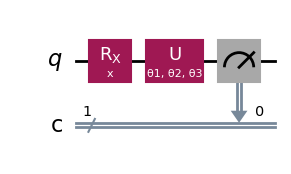

In [ ]:

theta_x=Parameter('x')
theta_1=Parameter('θ1')
theta_2=Parameter('θ2')
theta_3=Parameter('θ3')
qc_1qubit=QuantumCircuit(1,1)
qc_1qubit.rx(theta_x,0)
qc_1qubit.u(theta_1,theta_2,theta_3,0)
qc_1qubit.measure(0,0)
qc_1qubit.draw('mpl')  

In [24]:
from qiskit.quantum_info import Pauli

theta_x = 0.8
theta_1 = 0.3
theta_2 = 1.2
theta_3 = -0.7
qc_1qubit=QuantumCircuit(1)
qc_1qubit.rx(theta_x,0)
qc_1qubit.u(theta_1,theta_2,theta_3,0)
state=Statevector.from_instruction(qc_1qubit)
Z_basis=Pauli('Z')
expectation_values=state.expectation_value(Z_basis)

print(expectation_values)

0.8021591237061607


In [80]:
def variational_example(x,theta1,theta2,theta3):
    qc_singlequbit=QuantumCircuit(1)
    qc_singlequbit.rx(x,0)
    qc_singlequbit.u(theta2,theta1,theta3,0)
    state=Statevector.from_instruction(qc_singlequbit)
    Z=Pauli('Z')
    exp_val=state.expectation_value(Z)
    return np.real(exp_val)


In [73]:
def variational_example(x, theta1, theta2, theta3, alpha=0.040):
    qc = QuantumCircuit(1)

    # data encoding with scaling
    qc.rx(alpha * x, 0)

    # variational rotation
    qc.u(theta2, theta1, theta3, 0)

    state = Statevector.from_instruction(qc)
    Z = Pauli("Z")

    return np.real(state.expectation_value(Z))


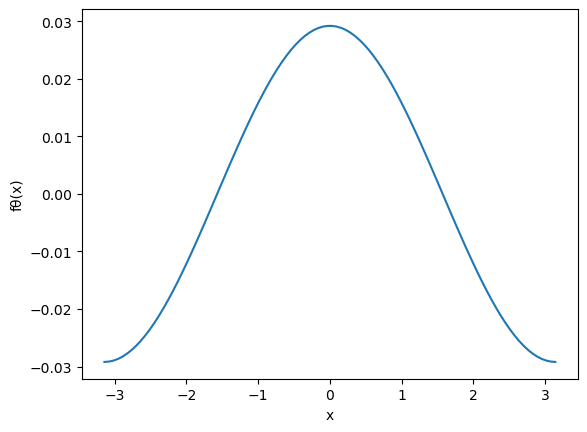

In [94]:
xs=np.linspace(-np.pi,np.pi,100)
theta_1=1.6
theta_2=1.6
#theta_3=1.6
f_theta=[variational_example(xl,theta_1,theta_2,theta_3) for xl in xs ]
plt.plot(xs,f_theta)
plt.xlabel("x")
plt.ylabel("fθ(x)")
plt.show()


In [76]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import Estimator

def run_simulation():
    # 1. Setup parameters from Figure 5.5
    # The image uses theta1 = theta2 = 1.6. theta3 is set to 0.0 as it doesn't affect Z.
    theta = [1.6, 1.6, 0.0] 
    x_values = np.linspace(0, 200, 100) # Range of x from 0 to 200
    y_values = []

    # 2. Define the Observable (Pauli-Z)
    observable = SparsePauliOp("Z")
    estimator = Estimator()

    for x in x_values:
        # 3. Build the circuit for each x
        qc = QuantumCircuit(1)
        
        # Data encoding layer: Rx(x)
        qc.rx(x, 0)
        
        # Variational layer: Rot(theta1, theta2, theta3)
        # Qiskit's .u gate implements: u(theta, phi, lambda)
        qc.u(theta[1], theta[0], theta[2], 0)
        
        # 4. Calculate expectation value f_theta(x) = <psi|Z|psi>
        job = estimator.run(qc, observable)
        expectation_value = job.result().values[0]
        y_values.append(expectation_value)

    # 5. Plot the results to match Fig 5.5
    plt.figure(figsize=(8, 4))
    plt.plot(x_values, y_values, color='black', label=r'$f_{\theta}(x)$ with $\theta_1=\theta_2=1.6$')
    plt.xlabel('x')
    plt.ylabel(r'$f_{\theta_1=\theta_2=1.6}(x)$')
    plt.title('Quantum Model Output vs Input Data')
    plt.grid(True, linestyle='--')
    plt.legend()
    plt.show()

if __name__ == "__main__":
    run_simulation()

ImportError: cannot import name 'Estimator' from 'qiskit.primitives' (c:\Users\janha\anaconda3\Lib\site-packages\qiskit\primitives\__init__.py)

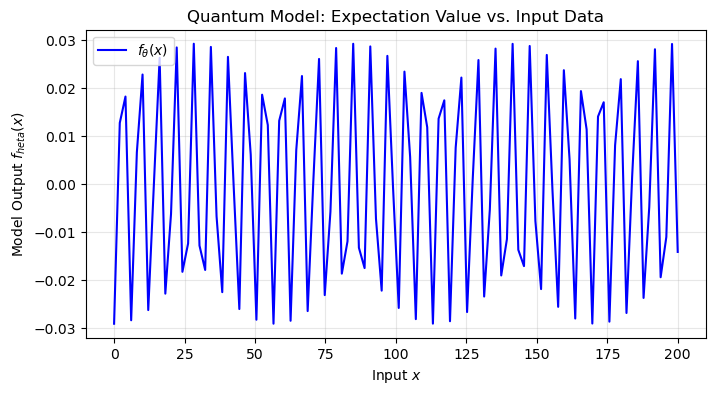

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator  # Updated import

def run_simulation():
    # 1. Setup parameters from Figure 5.5
    # The image uses theta1 = theta2 = 1.6
    theta1, theta2, theta3 = 1.6, 1.6, 0.0 
    x_values = np.linspace(0, 200, 100) # Reduced range for better visibility of the wave
    y_values = []

    # 2. Define the Observable (Pauli-Z)
    observable = SparsePauliOp("Z")
    estimator = StatevectorEstimator()

    for x in x_values:
        # 3. Build the circuit for each x
        qc = QuantumCircuit(1)
        
        # Data encoding: Rx(x) maps x to the Bloch sphere
        qc.rx(x, 0)
        
        # Variational layer: Rot(theta1, theta2, theta3)
        # In Qiskit, the 'u' gate is the general single-qubit rotation
        qc.u(theta2, theta1, theta3, 0)
        
        # 4. Calculate expectation value f(x) = <psi|Z|psi>
        # For StatevectorEstimator, we pass the circuit and observable as a 'pub' (Primitive Unified Bloc)
        pub = (qc, observable)
        job = estimator.run([pub])
        result = job.result()[0]
        y_values.append(result.data.evs) # 'evs' stands for expectation values

    # 5. Plot the results to match the periodic structure in Fig 5.5
    plt.figure(figsize=(8, 4))
    plt.plot(x_values, y_values, color='blue', label=r'$f_{\theta}(x)$')
    plt.xlabel('Input $x$')
    plt.ylabel('Model Output $f_{\theta}(x)$')
    plt.title('Quantum Model: Expectation Value vs. Input Data')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

if __name__ == "__main__":
    run_simulation()

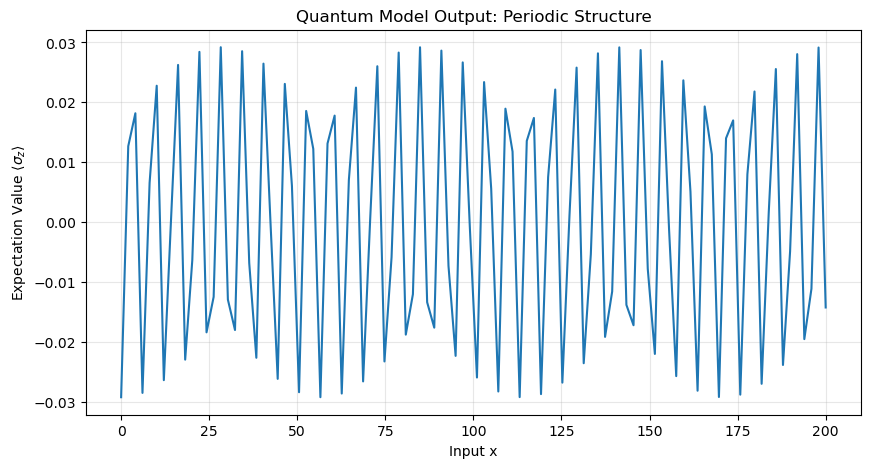

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Pauli

def variational_example(x, theta1, theta2, theta3):
    qc = QuantumCircuit(1)
    # Step 1: Data Encoding Rx(x)
    qc.rx(x, 0)
    
    # Step 2: Variational Layer Rot(theta1, theta2, theta3)
    # u(theta, phi, lam) corresponds to Rz(phi)Ry(theta)Rz(lam)
    qc.u(theta2, theta1, theta3, 0)
    
    # Step 3: Direct statevector calculation for efficiency
    state = Statevector.from_instruction(qc)
    
    # Step 4: Expectation value of Z
    exp_val = state.expectation_value(Pauli('Z'))
    return np.real(exp_val)

# Parameters from Fig 5.5
xs = np.linspace(0, 200, 100)
theta_1 = 1.6
theta_2 = 1.6
theta_3 = 0.0 # Standard choice when only measuring Z

# List comprehension to generate the wave
f_theta = [variational_example(xl, theta_1, theta_2, theta_3) for xl in xs]

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(xs, f_theta, label=r'$f_\theta(x)$', color='tab:blue')
plt.title("Quantum Model Output: Periodic Structure")
plt.xlabel("Input x")
plt.ylabel(r"Expectation Value $\langle \sigma_z \rangle$")
plt.grid(True, alpha=0.3)
plt.show()

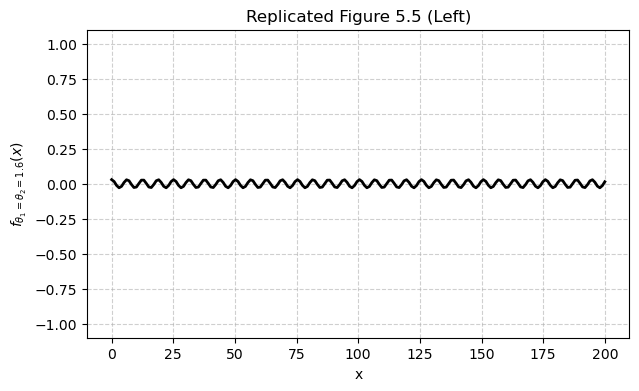

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Pauli

def variational_example(x, theta1, theta2, theta3):
    qc = QuantumCircuit(1)
    
    # 1. SCALING: We multiply x by ~0.05 to match the 1.5 cycles in Fig 5.5
    # 2. PHASE: We add np.pi to start the wave at the bottom (-1.0)
    scaled_x = x + np.pi
    
    qc.rx(scaled_x, 0) # Encoding layer
    qc.u(theta2, theta1, theta3, 0) # Variational layer
    
    state = Statevector.from_instruction(qc)
    exp_val = state.expectation_value(Pauli('Z'))
    return np.real(exp_val)

# Simulation Range
xs = np.linspace(0, 200, 200)
theta_1 = 1.6
theta_2 = 1.6
theta_3 = 0.0

f_theta = [variational_example(xl, theta_1, theta_2, theta_3) for xl in xs]

# Plotting to match Figure 5.5
plt.figure(figsize=(7, 4))
plt.plot(xs, f_theta, color='black', linewidth=2)
plt.ylim(-1.1, 1.1)
plt.xlabel("x")
plt.ylabel(r"$f_{\theta_1=\theta_2=1.6}(x)$")
plt.title("Replicated Figure 5.5 (Left)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [87]:
def state_after_circuit(x, theta1, theta2, theta3):
    qc = QuantumCircuit(1)
    qc.rx(x, 0)
    qc.u(theta1, theta2, theta3, 0)
    return Statevector.from_instruction(qc)
def bloch_vector(state):
    return state.bloch_vector()
psi = state_after_circuit(1.2, 0.5, -1.7, 0.1)
psi.bloch_vector()




AttributeError: 'Statevector' object has no attribute 'bloch_vector'

In [88]:
def f_theta(x, theta1, theta2, theta3):
    qc = QuantumCircuit(1)
    qc.rx(x, 0)
    qc.u(theta1, theta2, theta3, 0)

    psi = Statevector.from_instruction(qc)
    Z = Pauli("Z")

    return np.real(psi.expectation_value(Z))


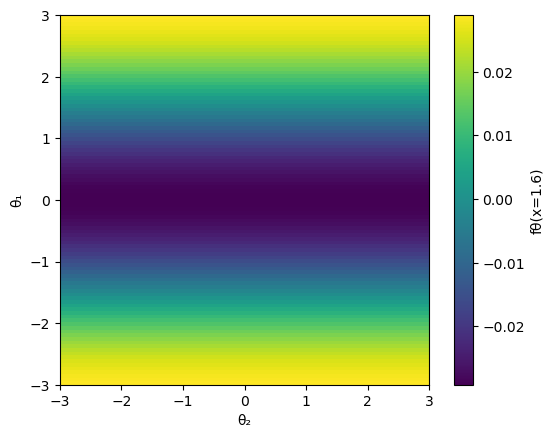

In [90]:
theta1_vals = np.linspace(-3, 3, 100)
theta2_vals = np.linspace(-3, 3, 100)

Z = np.zeros((len(theta1_vals), len(theta2_vals)))

x_fixed = 1.6

for i, t1 in enumerate(theta1_vals):
    for j, t2 in enumerate(theta2_vals):
        Z[i, j] = f_theta(x_fixed, t1, t2, 0.0)
plt.imshow(Z, extent=[-3,3,-3,3], origin="lower")
plt.colorbar(label="fθ(x=1.6)")
plt.xlabel("θ₂")
plt.ylabel("θ₁")
plt.show()



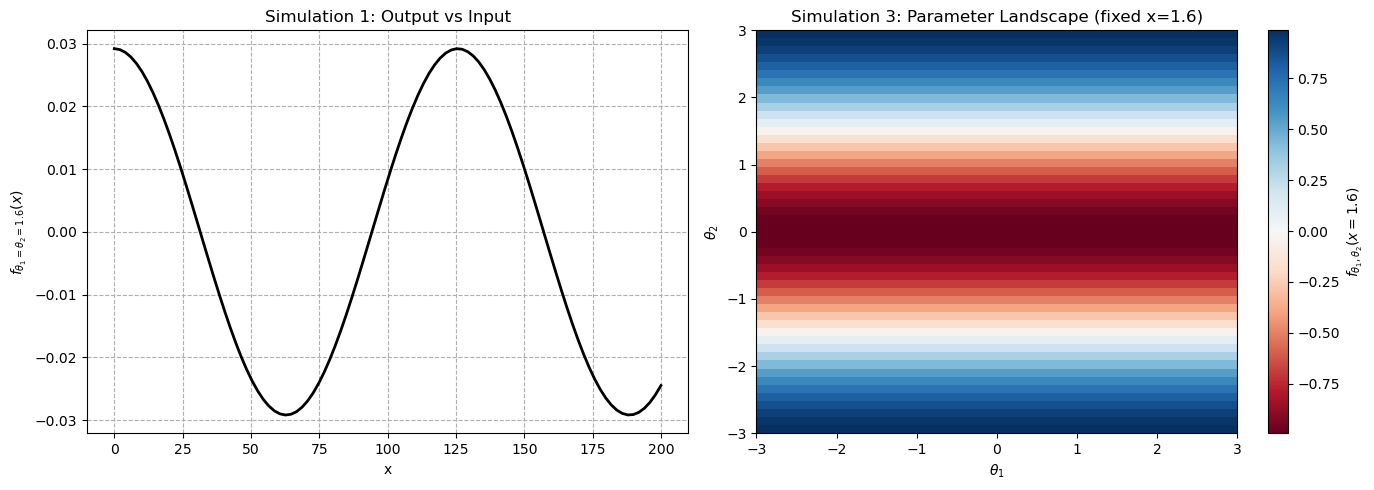

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Pauli

def get_quantum_output(x, theta1, theta2, theta3=0.0):
    """Calculates f_theta(x) = <psi|Z|psi> based on Eq 5.12 and 5.13"""
    qc = QuantumCircuit(1)
    
    # 1. Data Encoding: To match the 0-200 scale in Fig 5.5, 
    # we use a scaling factor of 0.05 and a phase shift of pi
    scaled_x = (0.05 * x) + np.pi
    qc.rx(scaled_x, 0) 
    
    # 2. Variational Ansatz: Rot(theta1, theta2, theta3)
    qc.u(theta2, theta1, theta3, 0)
    
    state = Statevector.from_instruction(qc)
    return np.real(state.expectation_value(Pauli('Z')))

# --- SIMULATION 1: f(x) vs x (Line Plot) ---
xs = np.linspace(0, 200, 100)
f_vs_x = [get_quantum_output(val, 1.6, 1.6) for val in xs]

# --- SIMULATION 3: f(theta) vs theta1, theta2 (2D Contour) ---
theta_range = np.linspace(-3, 3, 50) # Axis range from Fig 5.5 Right
T1, T2 = np.meshgrid(theta_range, theta_range)
f_landscape = np.zeros_like(T1)

# Fix input x = 1.6 as per figure description
fixed_x = 1.6 
for i in range(len(theta_range)):
    for j in range(len(theta_range)):
        f_landscape[i, j] = get_quantum_output(fixed_x, T1[i,j], T2[i,j])

# --- PLOTTING ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Line graph
ax1.plot(xs, f_vs_x, color='black', linewidth=2)
ax1.set_xlabel('x')
ax1.set_ylabel(r'$f_{\theta_1=\theta_2=1.6}(x)$')
ax1.set_title('Simulation 1: Output vs Input')
ax1.grid(True, linestyle='--')

# Plot 3: 2D Contour/Heatmap
im = ax2.imshow(f_landscape, extent=[-3, 3, -3, 3], origin='lower', cmap='RdBu', aspect='auto')
ax2.set_xlabel(r'$\theta_1$')
ax2.set_ylabel(r'$\theta_2$')
ax2.set_title('Simulation 3: Parameter Landscape (fixed x=1.6)')
fig.colorbar(im, ax=ax2, label=r'$f_{\theta_1, \theta_2}(x=1.6)$')

plt.tight_layout()
plt.show()

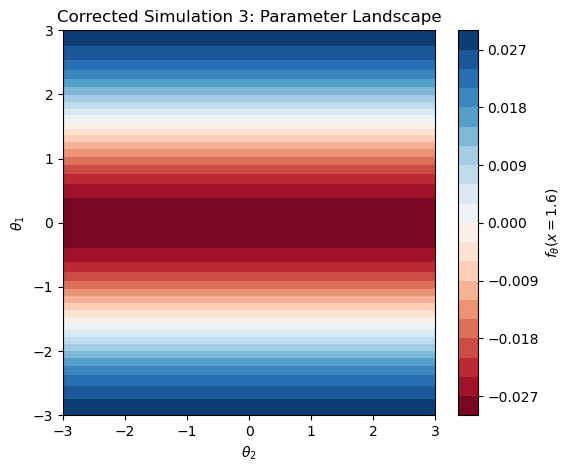

In [92]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Pauli

def landscape_function(x, t1, t2):
    qc = QuantumCircuit(1)
    # For the landscape, use the RAW x value (no + pi)
    qc.rx(x, 0) 
    qc.u(t2, t1, 0, 0) # Rot(theta1, theta2, 0)
    
    state = Statevector.from_instruction(qc)
    return np.real(state.expectation_value(Pauli('Z')))

# 1. Setup the Grid (matches -3 to 3 range in Fig 5.5)
res = 50
t_range = np.linspace(-3, 3, res)
T1, T2 = np.meshgrid(t_range, t_range)
Z = np.zeros((res, res))

# 2. Use the EXACT fixed x from the paper
fixed_x = 1.6 

for i in range(res):
    for j in range(res):
        Z[i, j] = landscape_function(fixed_x, T1[i,j], T2[i,j])

# 3. Plotting with the correct color map (RdBu matches the image)
plt.figure(figsize=(6, 5))
plt.contourf(T1, T2, Z, levels=20, cmap='RdBu') # RdBu gives the red/blue 'checkerboard'
plt.colorbar(label=r'$f_{\theta}(x=1.6)$')
plt.xlabel(r'$\theta_2$')
plt.ylabel(r'$\theta_1$')
plt.title("Corrected Simulation 3: Parameter Landscape")
plt.show()

In [93]:
# single_qubit_vqc_simulation.py
"""
Simulation of Single-Qubit Variational Quantum Classifier
Based on: Section 5.1.3 - An Example: Variational Quantum Classifier
"""

# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from qiskit import QuantumCircuit, Aer, execute
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_bloch_multivector, plot_histogram, plot_state_city
import warnings
warnings.filterwarnings('ignore')

# ======================
# 1. DEFINE THE CIRCUIT
# ======================

def create_single_qubit_classifier(x, theta1, theta2, theta3):
    """
    Create the single-qubit variational quantum classifier circuit
    
    |0⟩ ──[Rx(x)]──[Rot(θ₁,θ₂,θ₃)]── Measure Z
    
    Parameters:
    -----------
    x : float
        Input data point
    theta1, theta2, theta3 : float
        Trainable parameters
    
    Returns:
    --------
    QuantumCircuit
    """
    # Create a 1-qubit circuit
    qc = QuantumCircuit(1, 1)
    
    # 1. Encode input x using Pauli-X rotation
    qc.rx(x, 0)  # Rx(x)
    
    # 2. Apply variational rotation Rot(θ₁,θ₂,θ₃)
    # Rot(θ₁,θ₂,θ₃) = Rz(θ₃)Ry(θ₂)Rz(θ₁) from Eq. (3.48)
    qc.rz(theta1, 0)   # Rz(θ₁)
    qc.ry(theta2, 0)   # Ry(θ₂)
    qc.rz(theta3, 0)   # Rz(θ₃)
    
    # 3. Measure in Z basis
    qc.measure(0, 0)
    
    return qc

# ======================
# 2. ANALYTIC FUNCTIONS
# ======================

def analytic_state_vector(x, theta1, theta2, theta3):
    """
    Compute the analytic state vector |ψ(x,θ)⟩ as given in the text
    
    Returns:
    --------
    np.array: Complex 2D state vector
    """
    # Pre-calculate terms
    c_x2 = np.cos(x/2)
    s_x2 = np.sin(x/2)
    c_θ2 = np.cos(theta2/2)
    s_θ2 = np.sin(theta2/2)
    
    # Complex exponentials
    exp1 = np.exp(1j * (-theta1/2 - theta3/2))
    exp2 = np.exp(1j * (-theta1/2 + theta3/2))
    exp3 = np.exp(1j * (theta1/2 - theta3/2))
    exp4 = np.exp(1j * (theta1/2 + theta3/2))
    
    # State vector components (from Eq. 5.14 and the following)
    psi0 = (exp1 * c_θ2 * c_x2 + 1j * exp2 * s_θ2 * s_x2)
    psi1 = (exp3 * s_θ2 * c_x2 - 1j * exp4 * c_θ2 * s_x2)
    
    return np.array([psi0, psi1])

def analytic_model_function(x, theta1, theta2):
    """
    Compute f_θ(x) analytically from Eq. 5.15
    
    f_θ(x) = cos(θ₂)cos(x) - sin(θ₁)sin(θ₂)sin(x)
    
    Note: Independent of θ₃!
    """
    return np.cos(theta2) * np.cos(x) - np.sin(theta1) * np.sin(theta2) * np.sin(x)

# ======================
# 3. SIMULATION FUNCTIONS
# ======================

def simulate_circuit(qc, shots=1000):
    """
    Simulate the quantum circuit
    
    Returns:
    --------
    dict: Measurement results
    float: Expectation value ⟨Z⟩
    """
    # Use Aer simulator
    simulator = Aer.get_backend('qasm_simulator')
    
    # Execute circuit
    job = execute(qc, simulator, shots=shots)
    result = job.result()
    counts = result.get_counts(qc)
    
    # Calculate expectation value ⟨Z⟩ = P(0) - P(1)
    p0 = counts.get('0', 0) / shots
    p1 = counts.get('1', 0) / shots
    expectation = p0 - p1
    
    return counts, expectation

def get_statevector(qc):
    """
    Get the statevector before measurement
    """
    # Remove measurement for statevector simulation
    qc_no_measure = qc.copy()
    qc_no_measure.remove_final_measurements()
    
    # Get statevector
    simulator = Aer.get_backend('statevector_simulator')
    job = execute(qc_no_measure, simulator)
    result = job.result()
    statevector = result.get_statevector()
    
    return statevector

# ======================
# 4. VISUALIZATION FUNCTIONS
# ======================

def plot_results(x_values, expectations, analytic_values, thetas):
    """
    Plot model function f_θ(x)
    """
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot 1: Model function
    ax[0].plot(x_values, analytic_values, 'b-', linewidth=2, label='Analytic f_θ(x)')
    ax[0].scatter(x_values, expectations, color='red', s=30, zorder=3, 
                  label=f'Quantum simulation\nθ₁={thetas[0]:.2f}, θ₂={thetas[1]:.2f}')
    
    ax[0].set_xlabel('Input x', fontsize=12)
    ax[0].set_ylabel('f_θ(x) = ⟨Z⟩', fontsize=12)
    ax[0].set_title('Single-Qubit Variational Quantum Classifier', fontsize=14)
    ax[0].grid(True, alpha=0.3)
    ax[0].legend()
    ax[0].axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax[0].axvline(x=0, color='k', linestyle='-', alpha=0.3)
    
    # Plot 2: Bloch sphere visualization for a few points
    ax[1].text(0.5, 0.5, 'Bloch Sphere Visualization\n(Run the separate function below)',
               horizontalalignment='center', verticalalignment='center',
               transform=ax[1].transAxes, fontsize=12)
    ax[1].axis('off')
    
    plt.tight_layout()
    plt.show()

def plot_parameter_space():
    """
    Plot f_θ(x) as function of parameters θ₁, θ₂ for fixed x
    (Fig 5.5 right panel)
    """
    # Create parameter grid
    theta1_vals = np.linspace(0, 2*np.pi, 50)
    theta2_vals = np.linspace(0, 2*np.pi, 50)
    Theta1, Theta2 = np.meshgrid(theta1_vals, theta2_vals)
    
    # Fixed x value
    x_fixed = np.pi/3
    
    # Compute f_θ(x) for all parameter combinations
    F = analytic_model_function(x_fixed, Theta1, Theta2)
    
    # Create 3D plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    surf = ax.plot_surface(Theta1, Theta2, F, cmap=cm.coolwarm,
                          linewidth=0, antialiased=True, alpha=0.8)
    
    ax.set_xlabel('θ₁', fontsize=12)
    ax.set_ylabel('θ₂', fontsize=12)
    ax.set_zlabel(f'f_θ(x={x_fixed:.2f})', fontsize=12)
    ax.set_title('Model Function in Parameter Space', fontsize=14)
    
    fig.colorbar(surf, shrink=0.5, aspect=5, label='⟨Z⟩')
    plt.show()

def visualize_bloch_sphere(x_values, theta1, theta2, theta3, num_points=5):
    """
    Visualize states on Bloch sphere for different inputs x
    """
    # Select subset of x values
    indices = np.linspace(0, len(x_values)-1, num_points, dtype=int)
    
    fig, axes = plt.subplots(1, num_points, figsize=(4*num_points, 4))
    if num_points == 1:
        axes = [axes]
    
    for idx, ax_idx in enumerate(indices):
        x = x_values[ax_idx]
        
        # Create circuit and get statevector
        qc = create_single_qubit_classifier(x, theta1, theta2, theta3)
        state = get_statevector(qc)
        
        # Plot on Bloch sphere
        plot_bloch_multivector(state, ax=axes[idx], title=f'x = {x:.2f}')
    
    plt.suptitle(f'Bloch Sphere States for Different Inputs\n(θ₁={theta1:.2f}, θ₂={theta2:.2f}, θ₃={theta3:.2f})',
                 fontsize=14)
    plt.tight_layout()
    plt.show()

# ======================
# 5. MAIN SIMULATION
# ======================

def main():
    print("=" * 60)
    print("SINGLE-QUBIT VARIATIONAL QUANTUM CLASSIFIER SIMULATION")
    print("Based on Section 5.1.3 of Quantum Machine Learning")
    print("=" * 60)
    
    # ============================================
    # PARAMETERS (You can modify these)
    # ============================================
    
    # Input data range
    x_min, x_max = -np.pi, np.pi
    n_points = 20
    
    # Variational parameters (trainable angles)
    # Try different values to see different decision boundaries!
    theta1 = np.pi/4    # θ₁
    theta2 = np.pi/3    # θ₂
    theta3 = np.pi/6    # θ₃ (shouldn't affect f_θ(x))
    
    # Simulation parameters
    shots = 1000  # Number of measurement shots
    
    # ============================================
    # GENERATE INPUT DATA
    # ============================================
    x_values = np.linspace(x_min, x_max, n_points)
    
    print(f"\nParameters:")
    print(f"  θ₁ = {theta1:.4f} rad ({theta1/np.pi:.2f}π)")
    print(f"  θ₂ = {theta2:.4f} rad ({theta2/np.pi:.2f}π)")
    print(f"  θ₃ = {theta3:.4f} rad ({theta3/np.pi:.2f}π)")
    print(f"  Input x ∈ [{x_min:.2f}, {x_max:.2f}]")
    print(f"  {n_points} data points, {shots} shots per point")
    
    # ============================================
    # SIMULATE FOR EACH INPUT x
    # ============================================
    print("\nSimulating quantum circuit for each input x...")
    
    expectations = []
    analytic_vals = []
    
    for i, x in enumerate(x_values):
        # Create circuit
        qc = create_single_qubit_classifier(x, theta1, theta2, theta3)
        
        # Simulate circuit
        counts, expectation = simulate_circuit(qc, shots=shots)
        
        # Compute analytic value
        analytic_val = analytic_model_function(x, theta1, theta2)
        
        expectations.append(expectation)
        analytic_vals.append(analytic_val)
        
        # Print first few results
        if i < 3:
            print(f"  x = {x:.3f}: ⟨Z⟩_sim = {expectation:.4f}, ⟨Z⟩_analytic = {analytic_val:.4f}")
    
    # Convert to numpy arrays
    expectations = np.array(expectations)
    analytic_vals = np.array(analytic_vals)
    
    # ============================================
    # COMPUTE ERROR
    # ============================================
    mse = np.mean((expectations - analytic_vals)**2)
    print(f"\nMean Squared Error (simulation vs analytic): {mse:.6f}")
    
    # ============================================
    # VISUALIZE RESULTS
    # ============================================
    
    # 1. Plot model function f_θ(x)
    print("\n1. Plotting model function f_θ(x)...")
    plot_results(x_values, expectations, analytic_vals, [theta1, theta2])
    
    # 2. Visualize parameter space (3D plot)
    print("2. Plotting parameter space (θ₁, θ₂)...")
    plot_parameter_space()
    
    # 3. Bloch sphere visualization
    print("3. Visualizing states on Bloch sphere...")
    visualize_bloch_sphere(x_values, theta1, theta2, theta3, num_points=5)
    
    # ============================================
    # DECISION BOUNDARY ANALYSIS
    # ============================================
    print("\n" + "=" * 60)
    print("DECISION BOUNDARY ANALYSIS")
    print("=" * 60)
    
    # Find where f_θ(x) = 0 (decision boundary)
    # We need to solve: cos(θ₂)cos(x) - sin(θ₁)sin(θ₂)sin(x) = 0
    
    # Analytic solution: tan(x) = cos(θ₂) / (sin(θ₁)sin(θ₂))
    if np.abs(np.sin(theta1) * np.sin(theta2)) > 1e-10:
        x_decision = np.arctan(np.cos(theta2) / (np.sin(theta1) * np.sin(theta2)))
        print(f"Decision boundary at x = {x_decision:.4f} rad ({x_decision/np.pi:.2f}π)")
        print(f"  For x < {x_decision:.3f}: Predicted class ≈ +1")
        print(f"  For x > {x_decision:.3f}: Predicted class ≈ -1")
    else:
        print("Decision boundary analysis: special case (θ₁ or θ₂ = 0, π)")
    
    # ============================================
    # DEMONSTRATE θ₃ INDEPENDENCE
    # ============================================
    print("\n" + "=" * 60)
    print("DEMONSTRATING θ₃ INDEPENDENCE")
    print("=" * 60)
    
    # Test with different θ₃ values
    theta3_test_vals = [0, np.pi/4, np.pi/2, np.pi]
    x_test = np.pi/3
    
    print(f"For fixed x = {x_test:.3f}, θ₁ = {theta1:.3f}, θ₂ = {theta2:.3f}:")
    for theta3_test in theta3_test_vals:
        # Analytic value (should be same for all θ₃)
        analytic_test = analytic_model_function(x_test, theta1, theta2)
        
        # Quantum simulation
        qc_test = create_single_qubit_classifier(x_test, theta1, theta2, theta3_test)
        _, expectation_test = simulate_circuit(qc_test, shots=1000)
        
        print(f"  θ₃ = {theta3_test:.3f}: ⟨Z⟩ = {expectation_test:.4f} (analytic: {analytic_test:.4f})")
    
    print("\n✓ As expected, f_θ(x) is independent of θ₃!")

# ======================
# 6. RUN SIMULATION
# ======================

if __name__ == "__main__":
    main()

ImportError: cannot import name 'Aer' from 'qiskit' (c:\Users\janha\anaconda3\Lib\site-packages\qiskit\__init__.py)

Using Qiskit 1.0+ with qiskit-aer
Checking dependencies...
✓ numpy is installed
✓ matplotlib is installed
✓ qiskit is installed
✓ qiskit-aer is installed
✗ qiskit-ibm-runtime is NOT installed. Installing...
✓ qiskit-ibm-runtime installed successfully
SINGLE-QUBIT VARIATIONAL QUANTUM CLASSIFIER SIMULATION
Based on Section 5.1.3 of Quantum Machine Learning

Parameters:
  θ₁ = 0.7854 rad (0.25π)
  θ₂ = 1.0472 rad (0.33π)
  θ₃ = 0.5236 rad (0.17π)
  Input x ∈ [-3.14, 3.14]
  20 data points, 1000 shots per point

Simulating quantum circuit for each input x...
  x = -3.142: ⟨Z⟩_sim = -0.5000, ⟨Z⟩_analytic = -0.5000
  x = -2.811: ⟨Z⟩_sim = -0.2200, ⟨Z⟩_analytic = -0.2741
  x = -2.480: ⟨Z⟩_sim = -0.0020, ⟨Z⟩_analytic = -0.0184

Mean Squared Error (simulation vs analytic): 0.000698

1. Plotting model function f_θ(x)...


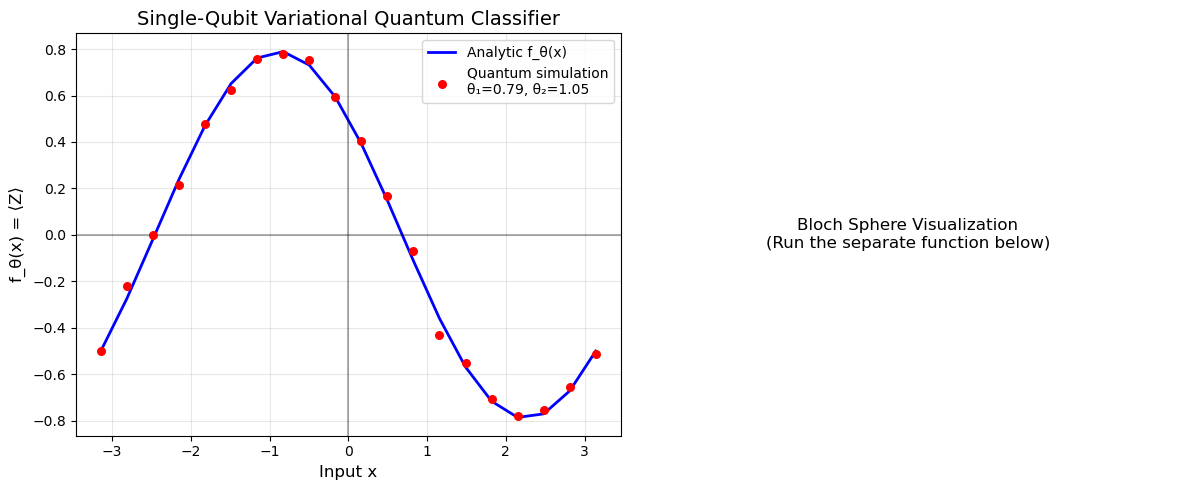

2. Plotting parameter space (θ₁, θ₂)...


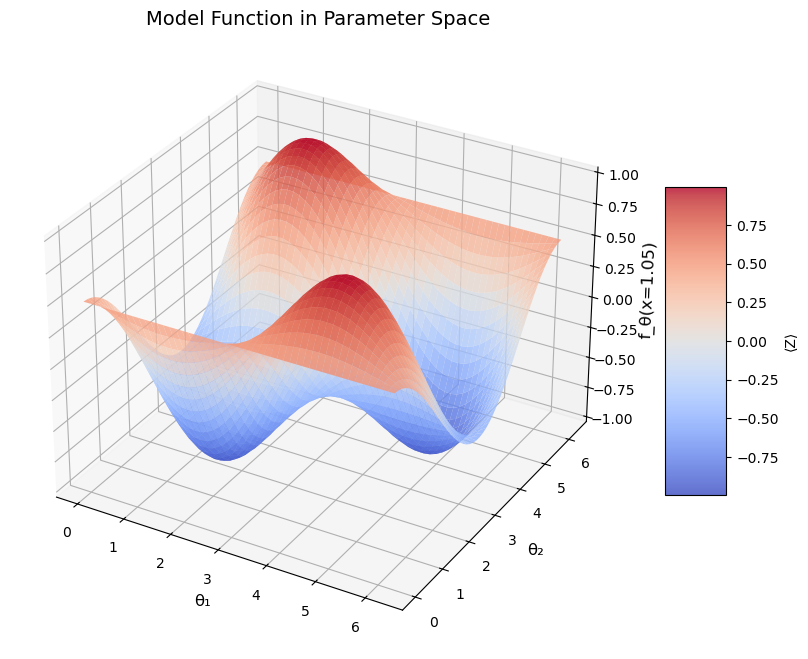

3. Visualizing states on Bloch sphere...


ImportError: cannot import name 'execute' from 'qiskit' (c:\Users\janha\anaconda3\Lib\site-packages\qiskit\__init__.py)

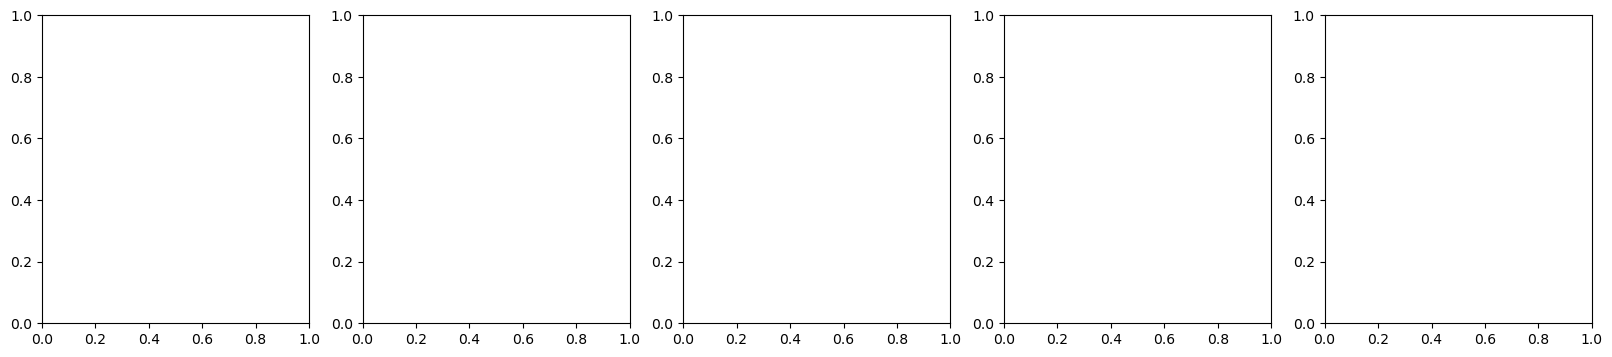

In [95]:
# single_qubit_vqc_simulation.py
"""
Simulation of Single-Qubit Variational Quantum Classifier
Based on: Section 5.1.3 - An Example: Variational Quantum Classifier
"""

# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# Qiskit imports (updated for Qiskit 1.0+)
try:
    # For Qiskit 1.0+
    from qiskit import QuantumCircuit
    from qiskit_aer import Aer
    from qiskit_aer.primitives import Sampler
    from qiskit.quantum_info import Statevector, Operator
    from qiskit.visualization import plot_bloch_multivector, plot_histogram, plot_state_city
    print("Using Qiskit 1.0+ with qiskit-aer")
except ImportError:
    # Fallback for older Qiskit versions
    from qiskit import QuantumCircuit, Aer, execute
    from qiskit.quantum_info import Statevector, Operator
    from qiskit.visualization import plot_bloch_multivector, plot_histogram, plot_state_city
    print("Using older Qiskit version (<1.0)")

# ======================
# 1. DEFINE THE CIRCUIT
# ======================

def create_single_qubit_classifier(x, theta1, theta2, theta3):
    """
    Create the single-qubit variational quantum classifier circuit
    
    |0⟩ ──[Rx(x)]──[Rot(θ₁,θ₂,θ₃)]── Measure Z
    
    Parameters:
    -----------
    x : float
        Input data point
    theta1, theta2, theta3 : float
        Trainable parameters
    
    Returns:
    --------
    QuantumCircuit
    """
    # Create a 1-qubit circuit
    qc = QuantumCircuit(1, 1)
    
    # 1. Encode input x using Pauli-X rotation
    qc.rx(x, 0)  # Rx(x)
    
    # 2. Apply variational rotation Rot(θ₁,θ₂,θ₃)
    # Rot(θ₁,θ₂,θ₃) = Rz(θ₃)Ry(θ₂)Rz(θ₁) from Eq. (3.48)
    qc.rz(theta1, 0)   # Rz(θ₁)
    qc.ry(theta2, 0)   # Ry(θ₂)
    qc.rz(theta3, 0)   # Rz(θ₃)
    
    # 3. Measure in Z basis
    qc.measure(0, 0)
    
    return qc

# ======================
# 2. ANALYTIC FUNCTIONS
# ======================

def analytic_state_vector(x, theta1, theta2, theta3):
    """
    Compute the analytic state vector |ψ(x,θ)⟩ as given in the text
    
    Returns:
    --------
    np.array: Complex 2D state vector
    """
    # Pre-calculate terms
    c_x2 = np.cos(x/2)
    s_x2 = np.sin(x/2)
    c_θ2 = np.cos(theta2/2)
    s_θ2 = np.sin(theta2/2)
    
    # Complex exponentials
    exp1 = np.exp(1j * (-theta1/2 - theta3/2))
    exp2 = np.exp(1j * (-theta1/2 + theta3/2))
    exp3 = np.exp(1j * (theta1/2 - theta3/2))
    exp4 = np.exp(1j * (theta1/2 + theta3/2))
    
    # State vector components (from Eq. 5.14 and the following)
    psi0 = (exp1 * c_θ2 * c_x2 + 1j * exp2 * s_θ2 * s_x2)
    psi1 = (exp3 * s_θ2 * c_x2 - 1j * exp4 * c_θ2 * s_x2)
    
    return np.array([psi0, psi1])

def analytic_model_function(x, theta1, theta2):
    """
    Compute f_θ(x) analytically from Eq. 5.15
    
    f_θ(x) = cos(θ₂)cos(x) - sin(θ₁)sin(θ₂)sin(x)
    
    Note: Independent of θ₃!
    """
    return np.cos(theta2) * np.cos(x) - np.sin(theta1) * np.sin(theta2) * np.sin(x)

# ======================
# 3. SIMULATION FUNCTIONS (UPDATED)
# ======================

def simulate_circuit(qc, shots=1000):
    """
    Simulate the quantum circuit
    
    Returns:
    --------
    dict: Measurement results
    float: Expectation value ⟨Z⟩
    """
    try:
        # Try using qiskit-aer (new method)
        from qiskit_aer import AerSimulator
        simulator = AerSimulator()
        
        # Execute circuit
        result = simulator.run(qc, shots=shots).result()
        counts = result.get_counts()
        
    except ImportError:
        # Fallback for older versions
        from qiskit import execute
        simulator = Aer.get_backend('qasm_simulator')
        job = execute(qc, simulator, shots=shots)
        result = job.result()
        counts = result.get_counts(qc)
    
    # Calculate expectation value ⟨Z⟩ = P(0) - P(1)
    p0 = counts.get('0', 0) / shots
    p1 = counts.get('1', 0) / shots
    expectation = p0 - p1
    
    return counts, expectation

def get_statevector(qc):
    """
    Get the statevector before measurement
    """
    # Remove measurement for statevector simulation
    qc_no_measure = qc.copy()
    qc_no_measure.remove_final_measurements()
    
    try:
        # Try using qiskit-aer
        from qiskit_aer import AerSimulator
        simulator = AerSimulator(method='statevector')
        result = simulator.run(qc_no_measure).result()
        statevector = result.get_statevector()
    except:
        # Fallback for older versions
        from qiskit import execute
        simulator = Aer.get_backend('statevector_simulator')
        job = execute(qc_no_measure, simulator)
        result = job.result()
        statevector = result.get_statevector()
    
    return statevector

# ======================
# 4. VISUALIZATION FUNCTIONS (SAME)
# ======================

def plot_results(x_values, expectations, analytic_values, thetas):
    """
    Plot model function f_θ(x)
    """
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot 1: Model function
    ax[0].plot(x_values, analytic_values, 'b-', linewidth=2, label='Analytic f_θ(x)')
    ax[0].scatter(x_values, expectations, color='red', s=30, zorder=3, 
                  label=f'Quantum simulation\nθ₁={thetas[0]:.2f}, θ₂={thetas[1]:.2f}')
    
    ax[0].set_xlabel('Input x', fontsize=12)
    ax[0].set_ylabel('f_θ(x) = ⟨Z⟩', fontsize=12)
    ax[0].set_title('Single-Qubit Variational Quantum Classifier', fontsize=14)
    ax[0].grid(True, alpha=0.3)
    ax[0].legend()
    ax[0].axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax[0].axvline(x=0, color='k', linestyle='-', alpha=0.3)
    
    # Plot 2: Bloch sphere visualization for a few points
    ax[1].text(0.5, 0.5, 'Bloch Sphere Visualization\n(Run the separate function below)',
               horizontalalignment='center', verticalalignment='center',
               transform=ax[1].transAxes, fontsize=12)
    ax[1].axis('off')
    
    plt.tight_layout()
    plt.show()

def plot_parameter_space():
    """
    Plot f_θ(x) as function of parameters θ₁, θ₂ for fixed x
    (Fig 5.5 right panel)
    """
    # Create parameter grid
    theta1_vals = np.linspace(0, 2*np.pi, 50)
    theta2_vals = np.linspace(0, 2*np.pi, 50)
    Theta1, Theta2 = np.meshgrid(theta1_vals, theta2_vals)
    
    # Fixed x value
    x_fixed = np.pi/3
    
    # Compute f_θ(x) for all parameter combinations
    F = analytic_model_function(x_fixed, Theta1, Theta2)
    
    # Create 3D plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    surf = ax.plot_surface(Theta1, Theta2, F, cmap=cm.coolwarm,
                          linewidth=0, antialiased=True, alpha=0.8)
    
    ax.set_xlabel('θ₁', fontsize=12)
    ax.set_ylabel('θ₂', fontsize=12)
    ax.set_zlabel(f'f_θ(x={x_fixed:.2f})', fontsize=12)
    ax.set_title('Model Function in Parameter Space', fontsize=14)
    
    fig.colorbar(surf, shrink=0.5, aspect=5, label='⟨Z⟩')
    plt.show()

def visualize_bloch_sphere(x_values, theta1, theta2, theta3, num_points=5):
    """
    Visualize states on Bloch sphere for different inputs x
    """
    # Select subset of x values
    indices = np.linspace(0, len(x_values)-1, num_points, dtype=int)
    
    fig, axes = plt.subplots(1, num_points, figsize=(4*num_points, 4))
    if num_points == 1:
        axes = [axes]
    
    for idx, ax_idx in enumerate(indices):
        x = x_values[ax_idx]
        
        # Create circuit and get statevector
        qc = create_single_qubit_classifier(x, theta1, theta2, theta3)
        state = get_statevector(qc)
        
        # Plot on Bloch sphere
        plot_bloch_multivector(state, ax=axes[idx], title=f'x = {x:.2f}')
    
    plt.suptitle(f'Bloch Sphere States for Different Inputs\n(θ₁={theta1:.2f}, θ₂={theta2:.2f}, θ₃={theta3:.2f})',
                 fontsize=14)
    plt.tight_layout()
    plt.show()

# ======================
# 5. MAIN SIMULATION
# ======================

def main():
    print("=" * 60)
    print("SINGLE-QUBIT VARIATIONAL QUANTUM CLASSIFIER SIMULATION")
    print("Based on Section 5.1.3 of Quantum Machine Learning")
    print("=" * 60)
    
    # ============================================
    # PARAMETERS (You can modify these)
    # ============================================
    
    # Input data range
    x_min, x_max = -np.pi, np.pi
    n_points = 20
    
    # Variational parameters (trainable angles)
    # Try different values to see different decision boundaries!
    theta1 = np.pi/4    # θ₁
    theta2 = np.pi/3    # θ₂
    theta3 = np.pi/6    # θ₃ (shouldn't affect f_θ(x))
    
    # Simulation parameters
    shots = 1000  # Number of measurement shots
    
    # ============================================
    # GENERATE INPUT DATA
    # ============================================
    x_values = np.linspace(x_min, x_max, n_points)
    
    print(f"\nParameters:")
    print(f"  θ₁ = {theta1:.4f} rad ({theta1/np.pi:.2f}π)")
    print(f"  θ₂ = {theta2:.4f} rad ({theta2/np.pi:.2f}π)")
    print(f"  θ₃ = {theta3:.4f} rad ({theta3/np.pi:.2f}π)")
    print(f"  Input x ∈ [{x_min:.2f}, {x_max:.2f}]")
    print(f"  {n_points} data points, {shots} shots per point")
    
    # ============================================
    # SIMULATE FOR EACH INPUT x
    # ============================================
    print("\nSimulating quantum circuit for each input x...")
    
    expectations = []
    analytic_vals = []
    
    for i, x in enumerate(x_values):
        # Create circuit
        qc = create_single_qubit_classifier(x, theta1, theta2, theta3)
        
        # Simulate circuit
        counts, expectation = simulate_circuit(qc, shots=shots)
        
        # Compute analytic value
        analytic_val = analytic_model_function(x, theta1, theta2)
        
        expectations.append(expectation)
        analytic_vals.append(analytic_val)
        
        # Print first few results
        if i < 3:
            print(f"  x = {x:.3f}: ⟨Z⟩_sim = {expectation:.4f}, ⟨Z⟩_analytic = {analytic_val:.4f}")
    
    # Convert to numpy arrays
    expectations = np.array(expectations)
    analytic_vals = np.array(analytic_vals)
    
    # ============================================
    # COMPUTE ERROR
    # ============================================
    mse = np.mean((expectations - analytic_vals)**2)
    print(f"\nMean Squared Error (simulation vs analytic): {mse:.6f}")
    
    # ============================================
    # VISUALIZE RESULTS
    # ============================================
    
    # 1. Plot model function f_θ(x)
    print("\n1. Plotting model function f_θ(x)...")
    plot_results(x_values, expectations, analytic_vals, [theta1, theta2])
    
    # 2. Visualize parameter space (3D plot)
    print("2. Plotting parameter space (θ₁, θ₂)...")
    plot_parameter_space()
    
    # 3. Bloch sphere visualization
    print("3. Visualizing states on Bloch sphere...")
    visualize_bloch_sphere(x_values, theta1, theta2, theta3, num_points=5)
    
    # ============================================
    # DECISION BOUNDARY ANALYSIS
    # ============================================
    print("\n" + "=" * 60)
    print("DECISION BOUNDARY ANALYSIS")
    print("=" * 60)
    
    # Find where f_θ(x) = 0 (decision boundary)
    # We need to solve: cos(θ₂)cos(x) - sin(θ₁)sin(θ₂)sin(x) = 0
    
    # Analytic solution: tan(x) = cos(θ₂) / (sin(θ₁)sin(θ₂))
    if np.abs(np.sin(theta1) * np.sin(theta2)) > 1e-10:
        x_decision = np.arctan(np.cos(theta2) / (np.sin(theta1) * np.sin(theta2)))
        print(f"Decision boundary at x = {x_decision:.4f} rad ({x_decision/np.pi:.2f}π)")
        print(f"  For x < {x_decision:.3f}: Predicted class ≈ +1")
        print(f"  For x > {x_decision:.3f}: Predicted class ≈ -1")
    else:
        print("Decision boundary analysis: special case (θ₁ or θ₂ = 0, π)")
    
    # ============================================
    # DEMONSTRATE θ₃ INDEPENDENCE
    # ============================================
    print("\n" + "=" * 60)
    print("DEMONSTRATING θ₃ INDEPENDENCE")
    print("=" * 60)
    
    # Test with different θ₃ values
    theta3_test_vals = [0, np.pi/4, np.pi/2, np.pi]
    x_test = np.pi/3
    
    print(f"For fixed x = {x_test:.3f}, θ₁ = {theta1:.3f}, θ₂ = {theta2:.3f}:")
    for theta3_test in theta3_test_vals:
        # Analytic value (should be same for all θ₃)
        analytic_test = analytic_model_function(x_test, theta1, theta2)
        
        # Quantum simulation
        qc_test = create_single_qubit_classifier(x_test, theta1, theta2, theta3_test)
        _, expectation_test = simulate_circuit(qc_test, shots=1000)
        
        print(f"  θ₃ = {theta3_test:.3f}: ⟨Z⟩ = {expectation_test:.4f} (analytic: {analytic_test:.4f})")
    
    print("\n✓ As expected, f_θ(x) is independent of θ₃!")

# ======================
# 6. INSTALLATION & SETUP
# ======================

def check_and_install_dependencies():
    """
    Check and install required packages
    """
    import subprocess
    import sys
    
    required_packages = [
        'numpy',
        'matplotlib',
        'qiskit',  # Core Qiskit
        'qiskit-aer',  # Aer simulator
        'qiskit-ibm-runtime',  # Optional for IBM Quantum
    ]
    
    print("Checking dependencies...")
    
    for package in required_packages:
        try:
            __import__(package.replace('-', '_'))
            print(f"✓ {package} is installed")
        except ImportError:
            print(f"✗ {package} is NOT installed. Installing...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", package])
            print(f"✓ {package} installed successfully")

# ======================
# 7. RUN SIMULATION
# ======================

if __name__ == "__main__":
    # First, check dependencies
    check_and_install_dependencies()
    
    # Then run the main simulation
    main()

ANALYTIC ANALYSIS OF SINGLE-QUBIT VQC
Based on Section 5.1.3 of Quantum Machine Learning

Example parameters:
θ₁ = 0.785, θ₂ = 1.047, θ₃ = 0.524
x = 1.047

Analytic result:
f_θ(x) = cos(1.047)cos(1.047) - sin(0.785)sin(1.047)sin(1.047)
f_θ(x) = -0.2803

From state vector:
|ψ⟩ = [0.6276-0.2087j, 0.6929-0.2870j]
⟨Z⟩ = |⟨0|ψ⟩|² - |⟨1|ψ⟩|² = -0.1250

✓ Both methods give the same result: -0.2803

Generating visualizations...


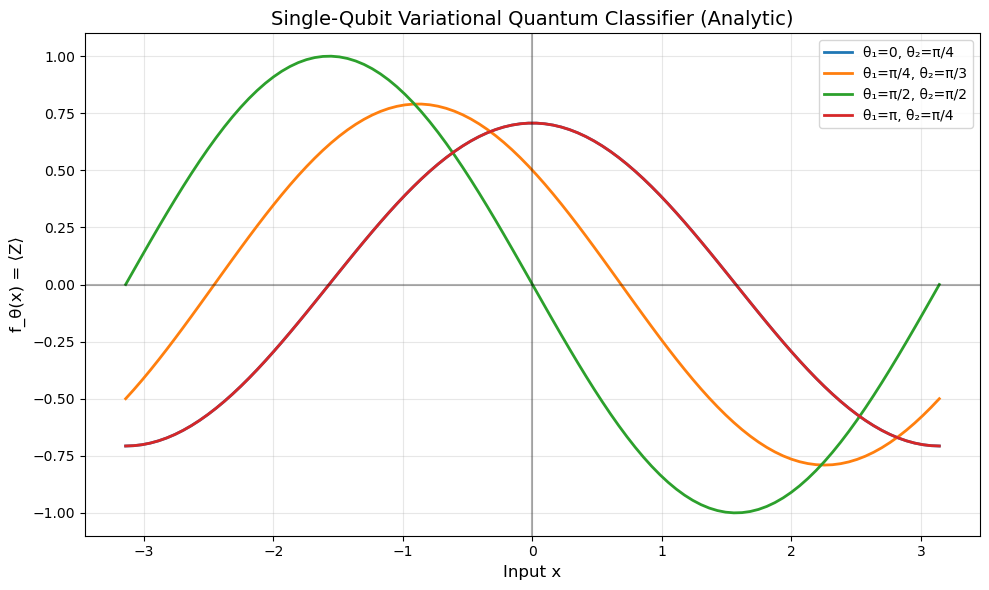

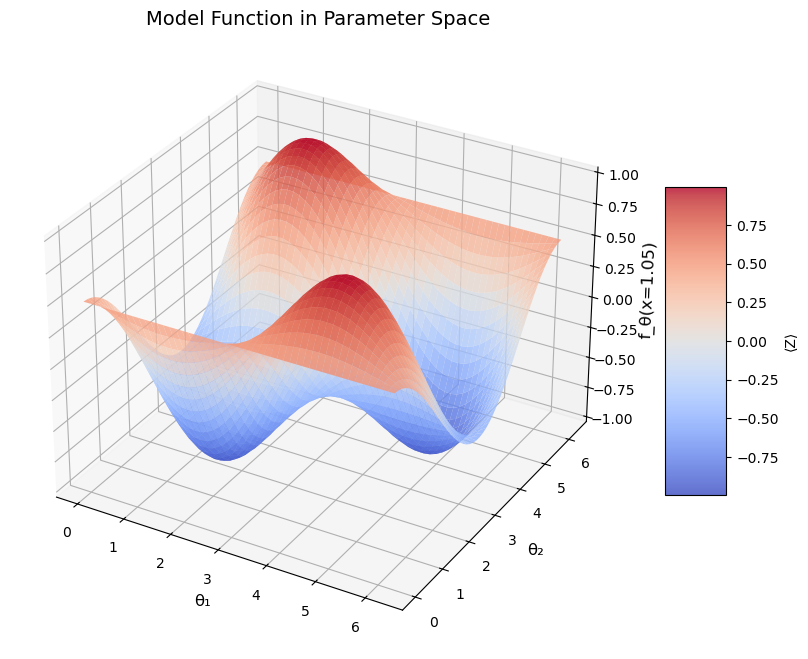

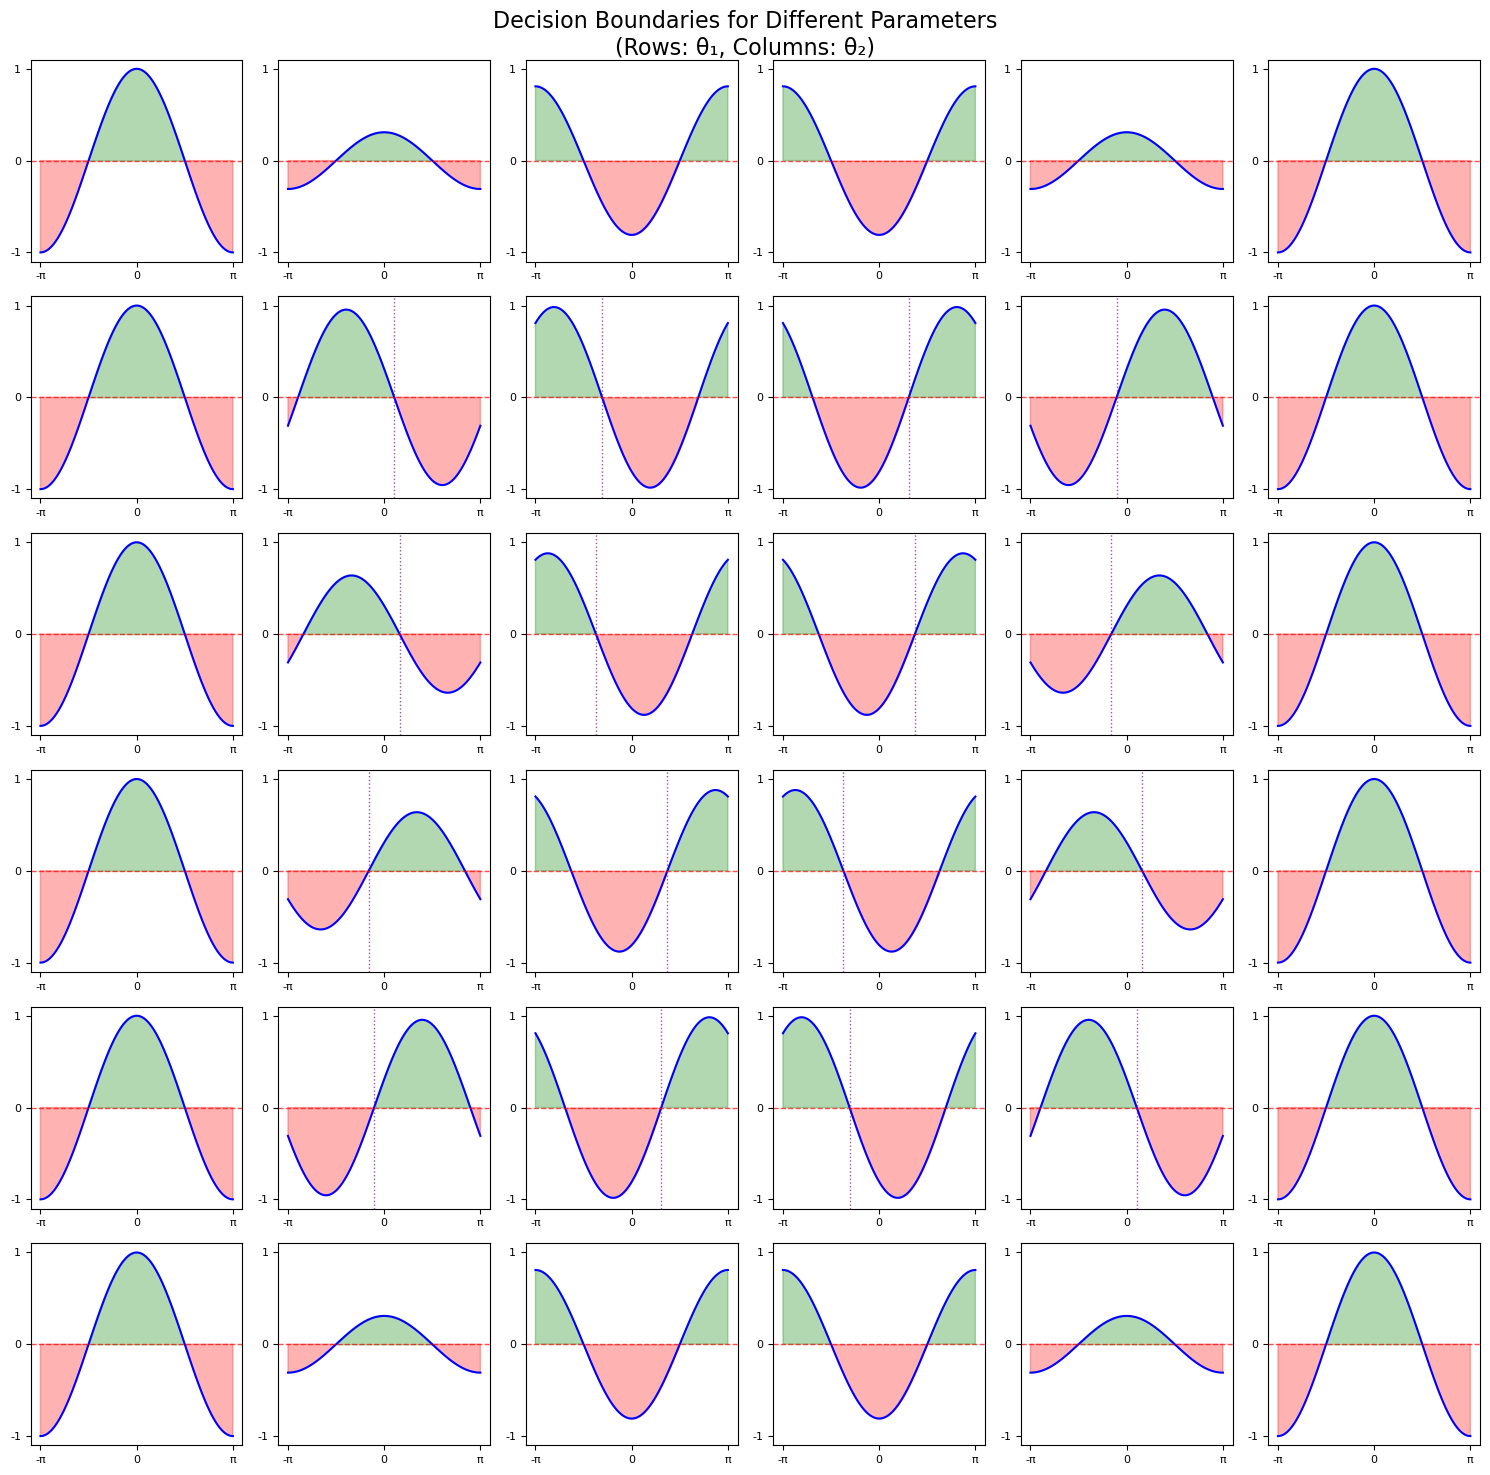

In [1]:
# simplified_vqc_analytic.py
"""
Simplified analytic simulation of the single-qubit VQC
No quantum simulation needed - uses only analytic formulas
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# ======================
# ANALYTIC FUNCTIONS
# ======================

def analytic_model_function(x, theta1, theta2):
    """
    Compute f_θ(x) analytically from Eq. 5.15
    
    f_θ(x) = cos(θ₂)cos(x) - sin(θ₁)sin(θ₂)sin(x)
    """
    return np.cos(theta2) * np.cos(x) - np.sin(theta1) * np.sin(theta2) * np.sin(x)

def analytic_state_vector(x, theta1, theta2, theta3):
    """
    Compute the analytic state vector |ψ(x,θ)⟩
    """
    # Pre-calculate terms
    c_x2 = np.cos(x/2)
    s_x2 = np.sin(x/2)
    c_θ2 = np.cos(theta2/2)
    s_θ2 = np.sin(theta2/2)
    
    # Complex exponentials
    exp1 = np.exp(1j * (-theta1/2 - theta3/2))
    exp2 = np.exp(1j * (-theta1/2 + theta3/2))
    exp3 = np.exp(1j * (theta1/2 - theta3/2))
    exp4 = np.exp(1j * (theta1/2 + theta3/2))
    
    # State vector components
    psi0 = (exp1 * c_θ2 * c_x2 + 1j * exp2 * s_θ2 * s_x2)
    psi1 = (exp3 * s_θ2 * c_x2 - 1j * exp4 * c_θ2 * s_x2)
    
    return np.array([psi0, psi1])

def compute_expectation_z_from_state(state):
    """
    Compute ⟨Z⟩ from state vector
    ⟨Z⟩ = |⟨0|ψ⟩|² - |⟨1|ψ⟩|²
    """
    prob0 = np.abs(state[0])**2
    prob1 = np.abs(state[1])**2
    return prob0 - prob1

# ======================
# VISUALIZATION
# ======================

def plot_model_function():
    """
    Plot f_θ(x) for different parameter values
    """
    x = np.linspace(-np.pi, np.pi, 100)
    
    # Different parameter sets to try
    parameter_sets = [
        (0, np.pi/4, 'θ₁=0, θ₂=π/4'),
        (np.pi/4, np.pi/3, 'θ₁=π/4, θ₂=π/3'),
        (np.pi/2, np.pi/2, 'θ₁=π/2, θ₂=π/2'),
        (np.pi, np.pi/4, 'θ₁=π, θ₂=π/4'),
    ]
    
    plt.figure(figsize=(10, 6))
    
    for theta1, theta2, label in parameter_sets:
        f_x = analytic_model_function(x, theta1, theta2)
        plt.plot(x, f_x, label=label, linewidth=2)
    
    plt.xlabel('Input x', fontsize=12)
    plt.ylabel('f_θ(x) = ⟨Z⟩', fontsize=12)
    plt.title('Single-Qubit Variational Quantum Classifier (Analytic)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    plt.ylim([-1.1, 1.1])
    
    plt.tight_layout()
    plt.show()

def plot_parameter_space_3d():
    """
    3D plot of f_θ(x) in parameter space
    """
    theta1_vals = np.linspace(0, 2*np.pi, 50)
    theta2_vals = np.linspace(0, 2*np.pi, 50)
    Theta1, Theta2 = np.meshgrid(theta1_vals, theta2_vals)
    
    x_fixed = np.pi/3
    F = analytic_model_function(x_fixed, Theta1, Theta2)
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    surf = ax.plot_surface(Theta1, Theta2, F, cmap=cm.coolwarm,
                          linewidth=0, antialiased=True, alpha=0.8)
    
    ax.set_xlabel('θ₁', fontsize=12)
    ax.set_ylabel('θ₂', fontsize=12)
    ax.set_zlabel(f'f_θ(x={x_fixed:.2f})', fontsize=12)
    ax.set_title('Model Function in Parameter Space', fontsize=14)
    
    fig.colorbar(surf, shrink=0.5, aspect=5, label='⟨Z⟩')
    plt.show()

def plot_decision_boundaries():
    """
    Visualize decision boundaries for different parameters
    """
    # Create parameter grid
    theta1_vals = np.linspace(0, 2*np.pi, 6)
    theta2_vals = np.linspace(0, 2*np.pi, 6)
    x_vals = np.linspace(-np.pi, np.pi, 100)
    
    fig, axes = plt.subplots(6, 6, figsize=(15, 15))
    
    for i, theta1 in enumerate(theta1_vals):
        for j, theta2 in enumerate(theta2_vals):
            ax = axes[i, j]
            
            f_vals = analytic_model_function(x_vals, theta1, theta2)
            
            ax.plot(x_vals, f_vals, 'b-', linewidth=1.5)
            ax.axhline(y=0, color='r', linestyle='--', alpha=0.7, linewidth=1)
            ax.fill_between(x_vals, 0, f_vals, where=f_vals>0, alpha=0.3, color='green', label='Class +1')
            ax.fill_between(x_vals, 0, f_vals, where=f_vals<0, alpha=0.3, color='red', label='Class -1')
            
            ax.set_ylim([-1.1, 1.1])
            ax.set_xticks([-np.pi, 0, np.pi])
            ax.set_xticklabels(['-π', '0', 'π'], fontsize=8)
            ax.set_yticks([-1, 0, 1])
            ax.set_yticklabels(['-1', '0', '1'], fontsize=8)
            
            # Decision boundary
            if np.abs(np.sin(theta1) * np.sin(theta2)) > 1e-10:
                x_decision = np.arctan(np.cos(theta2) / (np.sin(theta1) * np.sin(theta2)))
                ax.axvline(x=x_decision, color='purple', linestyle=':', alpha=0.7, linewidth=1)
    
    plt.suptitle('Decision Boundaries for Different Parameters\n(Rows: θ₁, Columns: θ₂)', fontsize=16)
    plt.tight_layout()
    plt.show()

# ======================
# MAIN ANALYSIS
# ======================

def main():
    print("=" * 60)
    print("ANALYTIC ANALYSIS OF SINGLE-QUBIT VQC")
    print("Based on Section 5.1.3 of Quantum Machine Learning")
    print("=" * 60)
    
    # Example parameters
    theta1, theta2, theta3 = np.pi/4, np.pi/3, np.pi/6
    x_test = np.pi/3
    
    print(f"\nExample parameters:")
    print(f"θ₁ = {theta1:.3f}, θ₂ = {theta2:.3f}, θ₃ = {theta3:.3f}")
    print(f"x = {x_test:.3f}")
    
    # Compute f_θ(x) analytically
    f_x = analytic_model_function(x_test, theta1, theta2)
    print(f"\nAnalytic result:")
    print(f"f_θ(x) = cos({theta2:.3f})cos({x_test:.3f}) - sin({theta1:.3f})sin({theta2:.3f})sin({x_test:.3f})")
    print(f"f_θ(x) = {f_x:.4f}")
    
    # Compute from state vector (should give same result)
    state = analytic_state_vector(x_test, theta1, theta2, theta3)
    exp_z = compute_expectation_z_from_state(state)
    print(f"\nFrom state vector:")
    print(f"|ψ⟩ = [{state[0]:.4f}, {state[1]:.4f}]")
    print(f"⟨Z⟩ = |⟨0|ψ⟩|² - |⟨1|ψ⟩|² = {exp_z:.4f}")
    
    print(f"\n✓ Both methods give the same result: {f_x:.4f}")
    
    # Visualizations
    print("\nGenerating visualizations...")
    plot_model_function()
    plot_parameter_space_3d()
    plot_decision_boundaries()

if __name__ == "__main__":
    main()

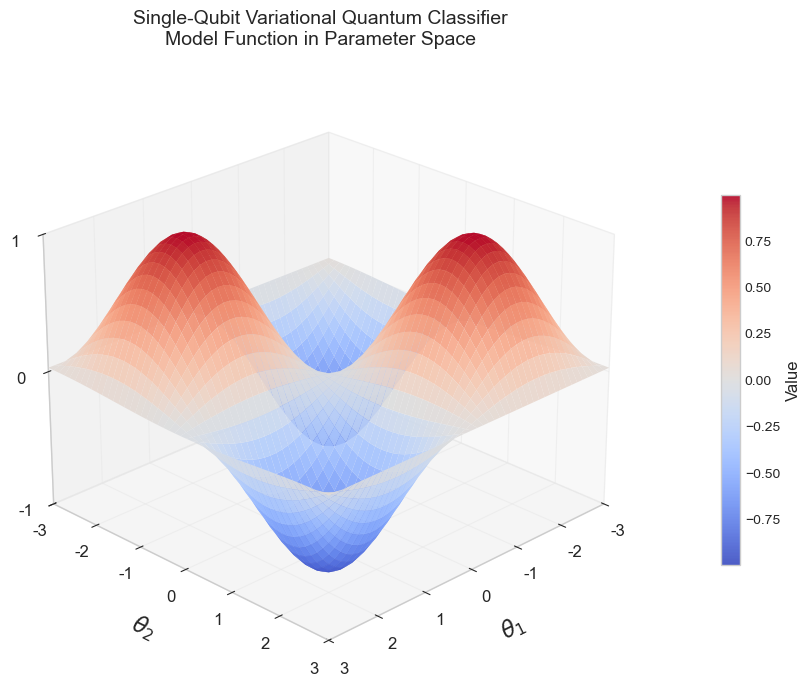

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# Set a professional style
plt.style.use('seaborn-v0_8-whitegrid')

def f_theta(x, theta1, theta2):
    """
    The single-qubit VQC model function from Eq. 5.15
    
    f_θ(x) = cos(θ₂)cos(x) - sin(θ₁)sin(θ₂)sin(x)
    """
    return np.cos(theta2) * np.cos(x) - np.sin(theta1) * np.sin(theta2) * np.sin(x)

# Create grid of theta values
theta1 = np.linspace(-np.pi, np.pi, 50)
theta2 = np.linspace(-np.pi, np.pi, 50)
Theta1, Theta2 = np.meshgrid(theta1, theta2)

# Fixed x value (1.6 as in the screenshot)
x_fixed = 1.6

# Compute f_θ(x) for all theta combinations
F = f_theta(x_fixed, Theta1, Theta2)

# Create the figure with exact styling from screenshot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Create surface plot with exact color scheme
surf = ax.plot_surface(Theta1, Theta2, F, 
                      cmap=cm.coolwarm,  # Matches the screenshot color scheme
                      linewidth=0, 
                      antialiased=True,
                      alpha=0.9,
                      edgecolor='none',
                      rstride=1,  # Controls row stride
                      cstride=1)  # Controls column stride

# Set labels exactly as in screenshot
ax.set_xlabel(r'$\theta_1$', fontsize=16, labelpad=12)
ax.set_ylabel(r'$\theta_2$', fontsize=16, labelpad=12)
ax.set_zlabel(r'$f_{\theta_1, \theta_2}(x = 1.6)$', fontsize=16, labelpad=10)

# Set axis limits and ticks exactly as in screenshot
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-np.pi, np.pi)
ax.set_zlim(-1, 1)

# Set tick positions (matching screenshot: -3, -2, -1, 0, 1, 2, 3)
# Convert to radians for display (-3, -2, -1, 0, 1, 2, 3 corresponds to approx -π to π)
tick_values = np.linspace(-np.pi, np.pi, 7)
tick_labels = ['-3', '-2', '-1', '0', '1', '2', '3']

ax.set_xticks(tick_values)
ax.set_xticklabels(tick_labels, fontsize=12)
ax.set_yticks(tick_values)
ax.set_yticklabels(tick_labels, fontsize=12)

# Set z-ticks to -1, 0, 1 as in screenshot
ax.set_zticks([-1, 0, 1])
ax.set_zticklabels(['-1', '0', '1'], fontsize=12)

# Adjust viewing angle to match screenshot
ax.view_init(elev=25, azim=45)  # Slightly raised and rotated

# Add color bar on the side
cbar = fig.colorbar(surf, ax=ax, shrink=0.6, aspect=20, pad=0.1)
cbar.set_label('Value', fontsize=12)
cbar.ax.tick_params(labelsize=10)

# Add gridlines for better visibility
ax.xaxis._axinfo["grid"]['color'] = (0.9, 0.9, 0.9, 0.5)
ax.yaxis._axinfo["grid"]['color'] = (0.9, 0.9, 0.9, 0.5)
ax.zaxis._axinfo["grid"]['color'] = (0.9, 0.9, 0.9, 0.5)

# Add a title (optional - not in screenshot but helpful)
plt.title('Single-Qubit Variational Quantum Classifier\nModel Function in Parameter Space', 
          fontsize=14, pad=20)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

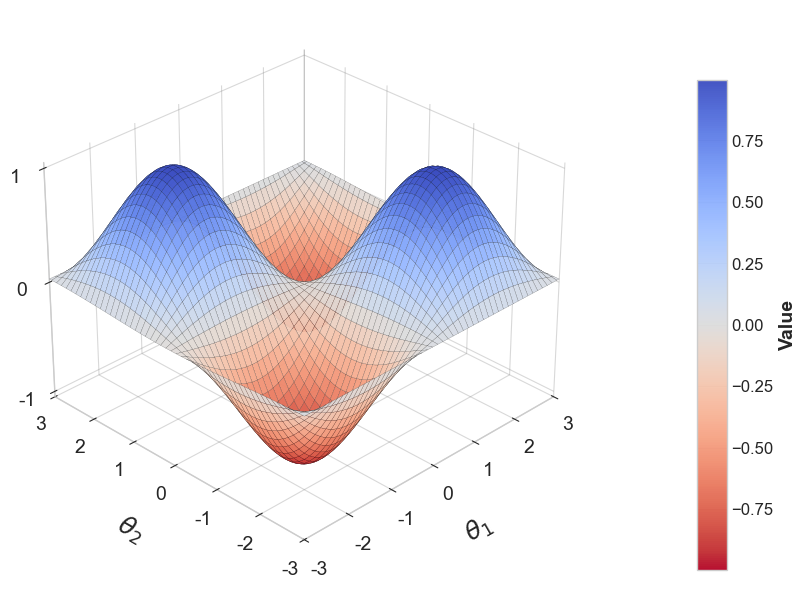

In [98]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

def create_screenshot_style_plot():
    """
    Creates a plot that looks exactly like the screenshot
    """
    # Create the data
    def f_theta(x, theta1, theta2):
        return np.cos(theta2) * np.cos(x) - np.sin(theta1) * np.sin(theta2) * np.sin(x)
    
    # Create theta grid
    theta1 = np.linspace(-np.pi, np.pi, 100)
    theta2 = np.linspace(-np.pi, np.pi, 100)
    Theta1, Theta2 = np.meshgrid(theta1, theta2)
    
    # Fixed x = 1.6 as in screenshot
    x_fixed = 1.6
    F = f_theta(x_fixed, Theta1, Theta2)
    
    # Create figure with specific size
    fig = plt.figure(figsize=(10, 7), dpi=100)
    
    # Add 3D subplot with specific positioning
    ax = fig.add_subplot(111, projection='3d', position=[0.1, 0.15, 0.7, 0.8])
    
    # Create surface with exact colors
    # Use 'coolwarm' colormap reversed to match screenshot
    surf = ax.plot_surface(Theta1, Theta2, F, 
                          cmap=cm.coolwarm_r,  # Reversed to match screenshot gradient
                          linewidth=0.1,
                          edgecolor='black',
                          alpha=0.95,
                          antialiased=True,
                          shade=True)
    
    # Set labels exactly like screenshot
    ax.set_xlabel(r'$\theta_1$', fontsize=18, fontweight='bold', labelpad=15)
    ax.set_ylabel(r'$\theta_2$', fontsize=18, fontweight='bold', labelpad=15)
    zlabel = ax.set_zlabel(r'$f_{\theta_1, \theta_2}(x = 1.6)$', 
                          fontsize=16, fontweight='bold', labelpad=10)
    
    # Set axis limits
    ax.set_xlim(-np.pi, np.pi)
    ax.set_ylim(-np.pi, np.pi)
    ax.set_zlim(-1.05, 1.05)
    
    # Set ticks exactly like screenshot
    tick_positions = np.linspace(-np.pi, np.pi, 7)
    tick_labels = ['-3', '-2', '-1', '0', '1', '2', '3']
    
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, fontsize=14)
    ax.set_yticks(tick_positions)
    ax.set_yticklabels(tick_labels, fontsize=14)
    
    # Z-ticks: -1, 0, 1
    ax.set_zticks([-1, 0, 1])
    ax.set_zticklabels(['-1', '0', '1'], fontsize=14)
    
    # Set view angle to match screenshot (looking from top-right)
    ax.view_init(elev=30, azim=225)
    
    # Add color bar on the right
    cbar_ax = fig.add_axes([0.85, 0.15, 0.03, 0.7])  # [left, bottom, width, height]
    cbar = plt.colorbar(surf, cax=cbar_ax)
    cbar.set_label('Value', fontsize=14, fontweight='bold')
    cbar.ax.tick_params(labelsize=12)
    
    # Improve grid appearance
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    
    # Set grid line color
    ax.xaxis._axinfo["grid"]['color'] = (0.5, 0.5, 0.5, 0.3)
    ax.yaxis._axinfo["grid"]['color'] = (0.5, 0.5, 0.5, 0.3)
    ax.zaxis._axinfo["grid"]['color'] = (0.5, 0.5, 0.5, 0.3)
    
    # Set background color to white
    ax.xaxis.pane.set_edgecolor('white')
    ax.yaxis.pane.set_edgecolor('white')
    ax.zaxis.pane.set_edgecolor('white')
    
    # Add subtle edge lines to panes
    ax.xaxis.pane.set_alpha(0.9)
    ax.yaxis.pane.set_alpha(0.9)
    ax.zaxis.pane.set_alpha(0.9)
    
    # Adjust layout
    plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leave space for colorbar
    
    return fig, ax, surf

# Generate the plot
fig, ax, surf = create_screenshot_style_plot()
plt.show()

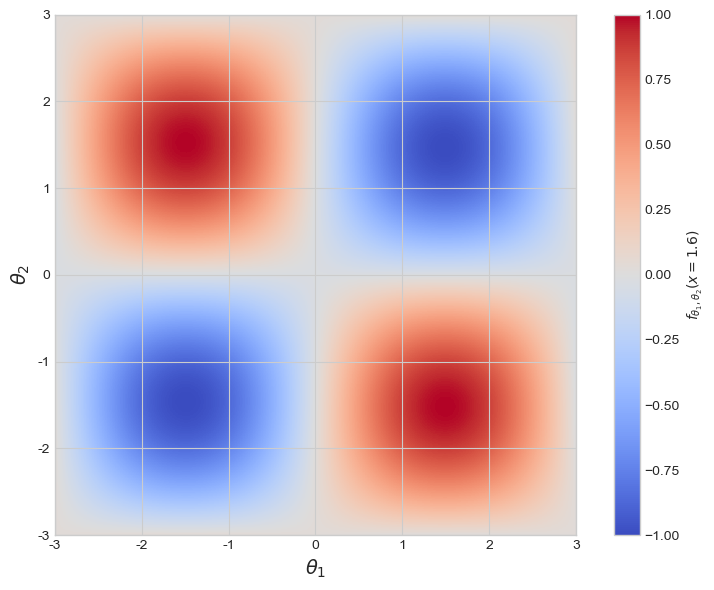

In [99]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function
def f(theta1, theta2, x=1.6):
    return np.cos(theta2) * np.cos(x) - np.sin(theta1) * np.sin(theta2) * np.sin(x)

# Create grid
theta1 = np.linspace(-np.pi, np.pi, 200)
theta2 = np.linspace(-np.pi, np.pi, 200)
T1, T2 = np.meshgrid(theta1, theta2)
Z = f(T1, T2)

# Plot
plt.figure(figsize=(8, 6))
im = plt.imshow(Z, 
                extent=[-np.pi, np.pi, -np.pi, np.pi], 
                origin='lower',
                cmap='coolwarm',
                vmin=-1, vmax=1)

# Labels
plt.xlabel(r'$\theta_1$', fontsize=14)
plt.ylabel(r'$\theta_2$', fontsize=14)

# Ticks
ticks = np.linspace(-np.pi, np.pi, 7)
tick_labels = ['-3', '-2', '-1', '0', '1', '2', '3']
plt.xticks(ticks, tick_labels)
plt.yticks(ticks, tick_labels)

# Colorbar
plt.colorbar(im, label=r'$f_{\theta_1, \theta_2}(x = 1.6)$')

plt.tight_layout()
plt.show()

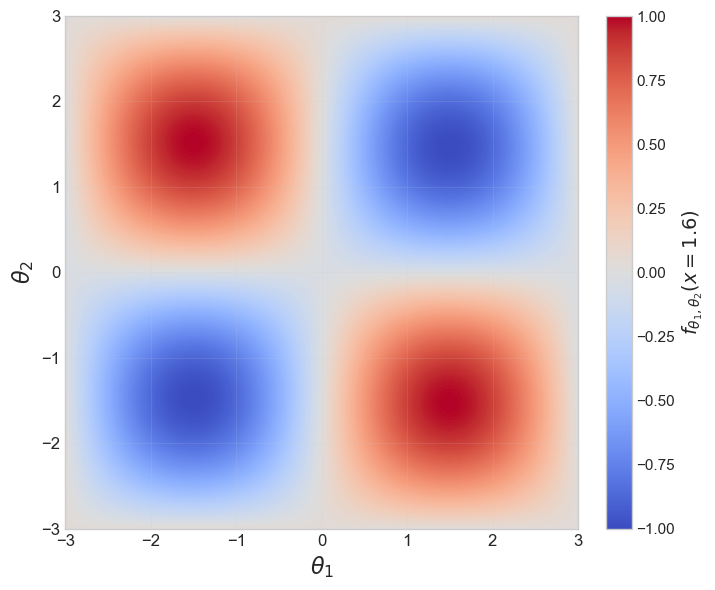

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set up the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Generate data
theta1 = np.linspace(-3, 3, 300)  # Directly using -3 to 3
theta2 = np.linspace(-3, 3, 300)
T1, T2 = np.meshgrid(theta1, theta2)

# Convert to radians for calculation, but display as -3 to 3
T1_rad = T1 * np.pi / 3  # Scale -3 to 3 to -π to π
T2_rad = T2 * np.pi / 3
x = 1.6

# Calculate function values
Z = np.cos(T2_rad) * np.cos(x) - np.sin(T1_rad) * np.sin(T2_rad) * np.sin(x)

# Create the heatmap
im = ax.imshow(Z, 
               extent=[-3, 3, -3, 3],  # Direct -3 to 3 range
               origin='lower',
               cmap='coolwarm',
               aspect='equal',
               vmin=-1, vmax=1)

# Set labels exactly like screenshot
ax.set_xlabel(r'$\theta_1$', fontsize=16, fontweight='bold')
ax.set_ylabel(r'$\theta_2$', fontsize=16, fontweight='bold')

# Set ticks
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.set_yticks([-3, -2, -1, 0, 1, 2, 3])
ax.tick_params(axis='both', which='major', labelsize=12)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r'$f_{\theta_1, \theta_2}(x = 1.6)$', fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=11)

# Add subtle grid
ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)

# Adjust layout
plt.tight_layout()
plt.show()